# END-TO-END ML WORKFLOW

## Step 1: Problem Framing & Performance Measure Selection
* **Objective:** Predict median house values in California districts based on given features.
* **Task Type:** Supervised Learning, Multiple Regression.
* **Performance Measure:** Root Mean Square Error (RMSE).

## Step 2: Data Collection
Automate the process of fetching raw data and set aside a Test Set to ensure unbiased evaluation.

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Fetch raw data
df = pd.read_csv('..\..\Data\ML_extra\housing.csv')
print("----- Data Info -----")
print(df.info())

print("\n----- Missing Values -----")
print(df.isnull().sum())

print("\n----- Duplicated Rows -----")
print(f"Total duplicates: {df.duplicated().sum()}")

print("\n----- Descriptive Statistics (Check Outliers/Anomalies) -----")
# Check descriptive stats for outliers or weird values like negative house prices, age, etc.
print(df.describe().to_string())

# 2. Set aside a Test Set
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print("\n----- Data Splitting -----")
print(f"Training set size: {len(train_set)} samples")
print(f"Test set size: {len(test_set)} samples")

----- Data Info -----
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

----- Missing Values -----
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
med

## Step 3: Exploratory Data Analysis (EDA) & Visualization
Use visualization and correlation matrices to uncover hidden patterns, detect outliers, and gain data insights.

### Code

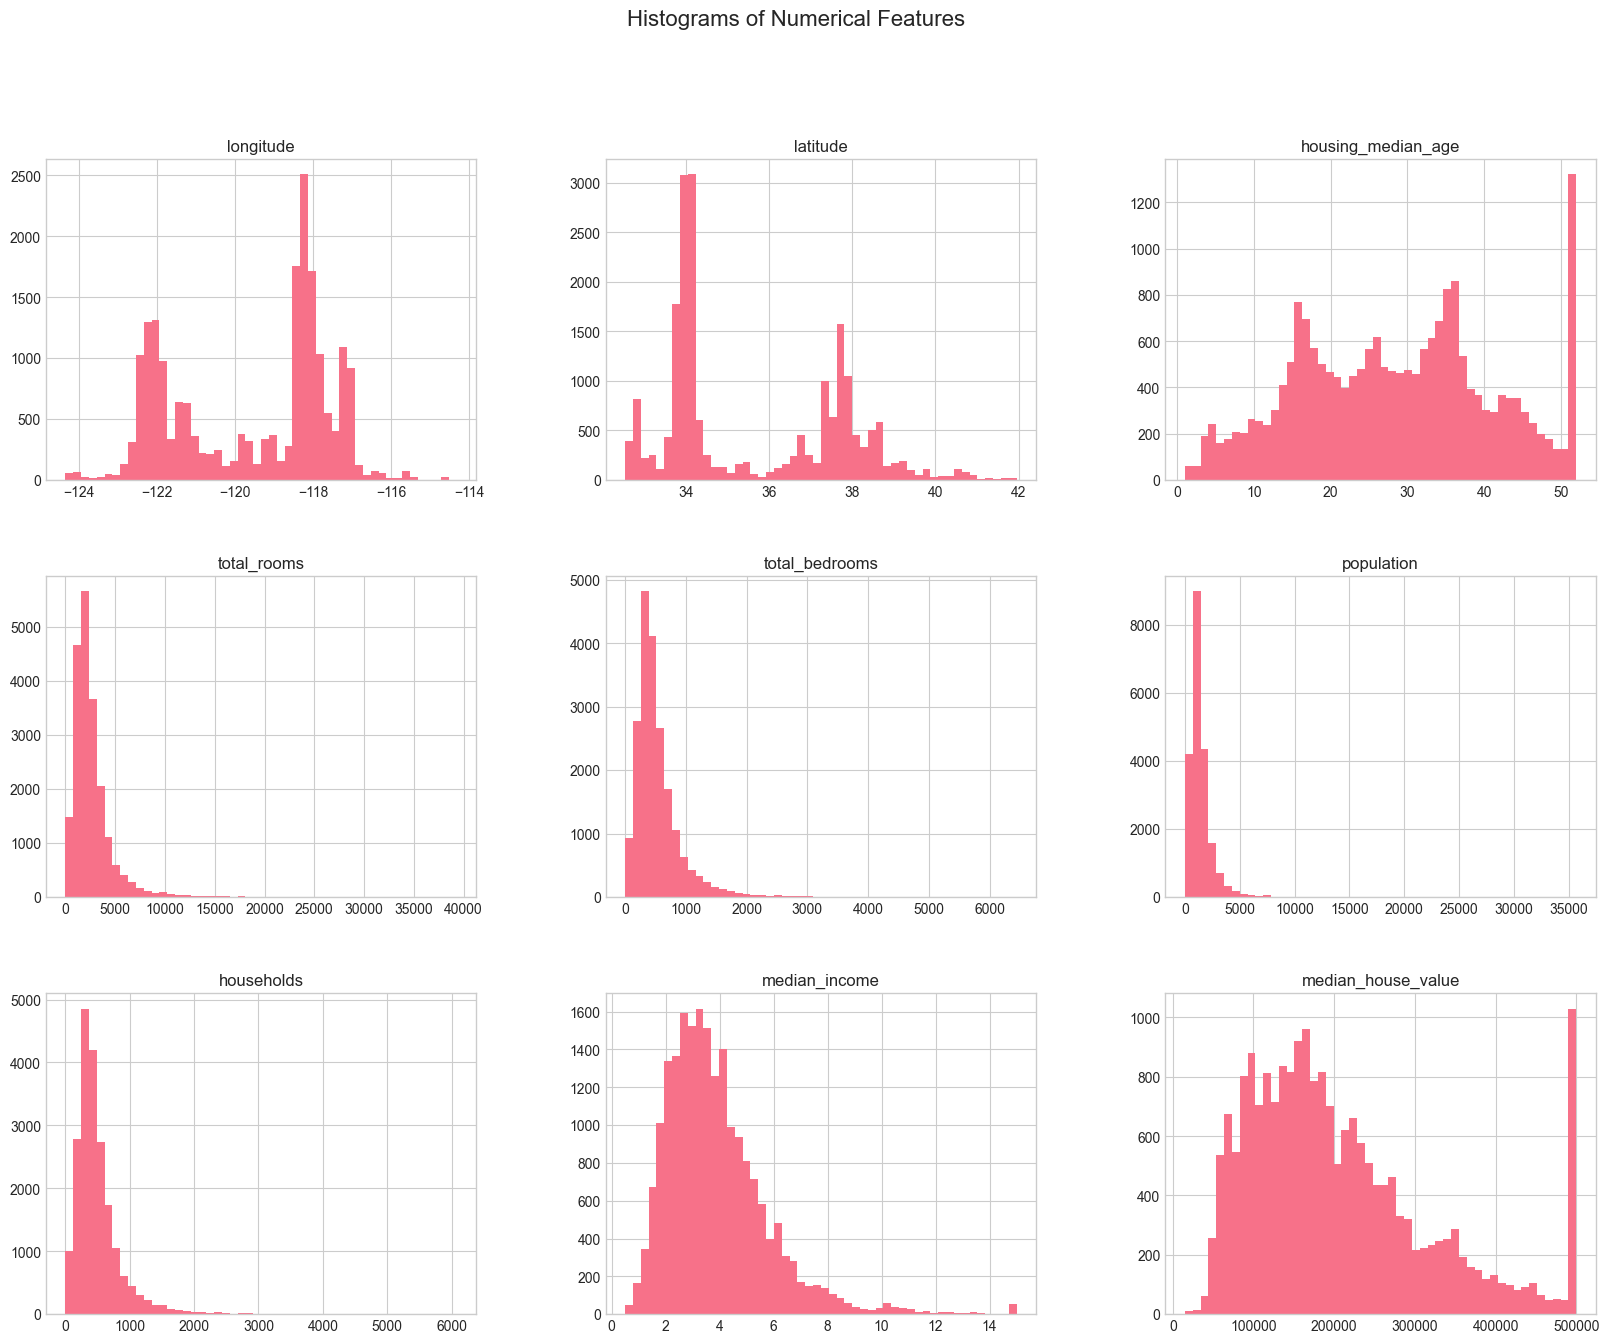

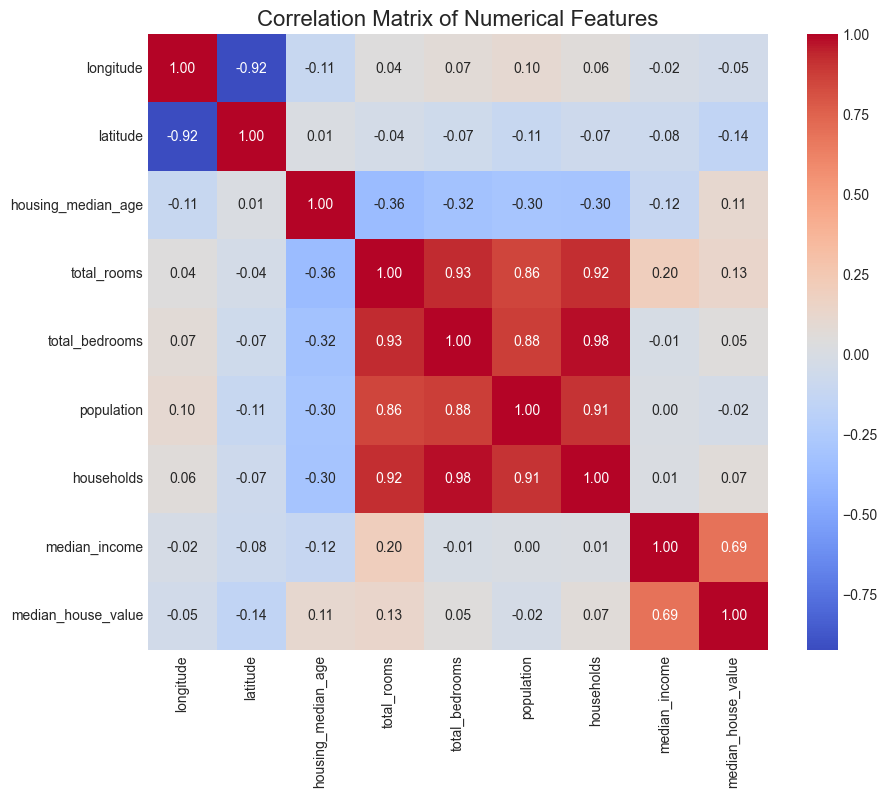

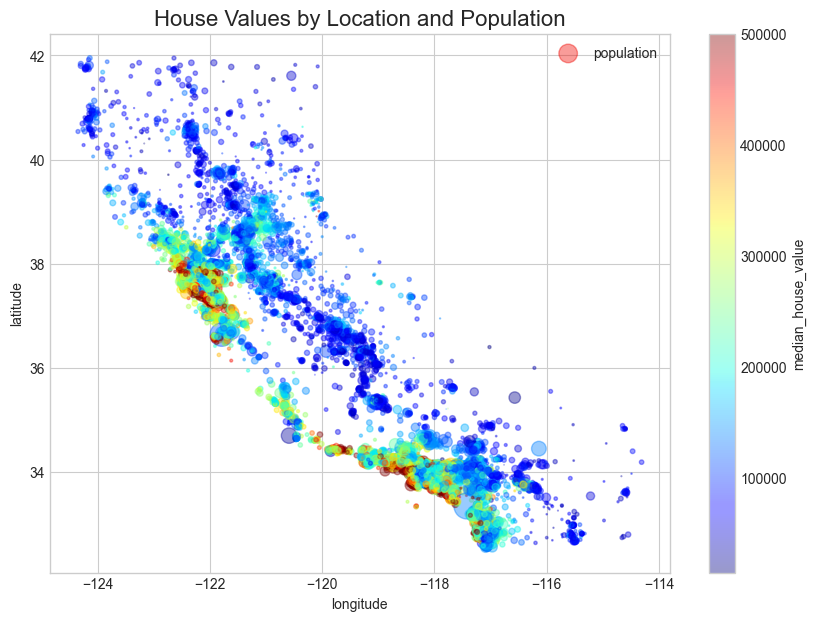

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1. Histograms of numerical features
df.hist(bins=50, figsize=(20, 15))
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()

# 2. Correlation Matrix
plt.figure(figsize=(10, 8))
# Exclude the non-numerical column 'ocean_proximity' for correlation calculation
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

# 3. Scatter plot of geographical attributes and house values
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=df["population"]/100, label="population", figsize=(10,7),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
    sharex=False)
plt.title('House Values by Location and Population', fontsize=16)
plt.legend()
plt.show()

### Chi tiết hóa độ tương quan giữa các đặc trưng (Features Correlation)
Sử dụng `scatter_matrix` của pandas để quan sát trực quan mối tương quan giữa các đặc trưng (features) ảnh hưởng lớn nhất.

Correlation with median_house_value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


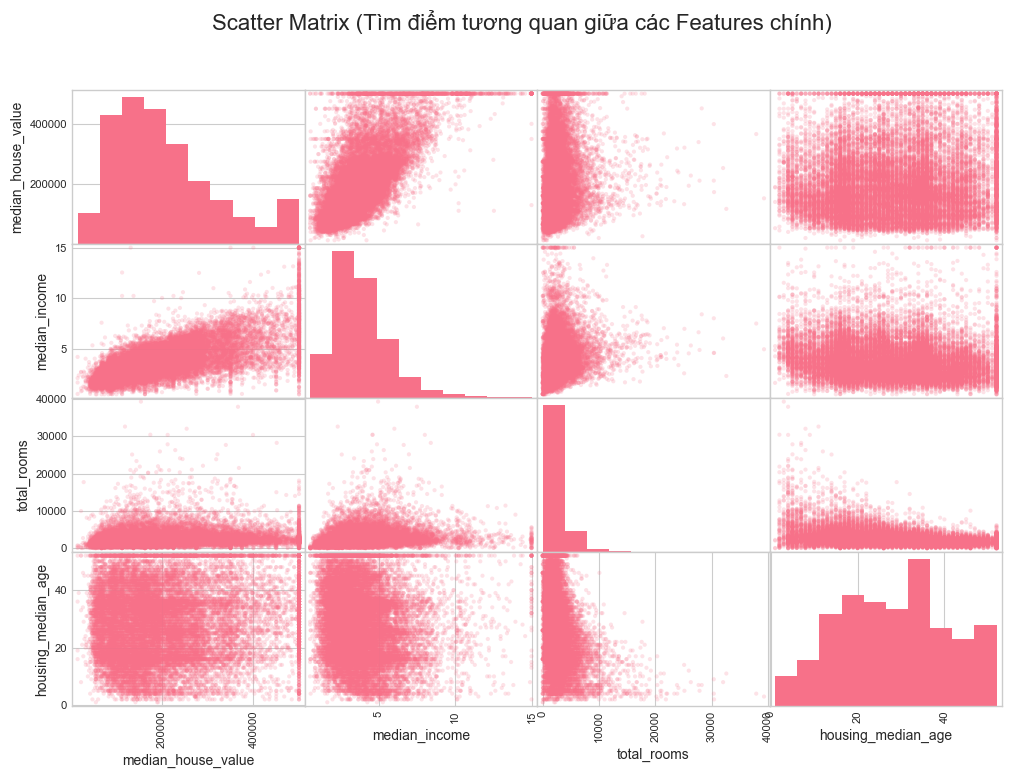

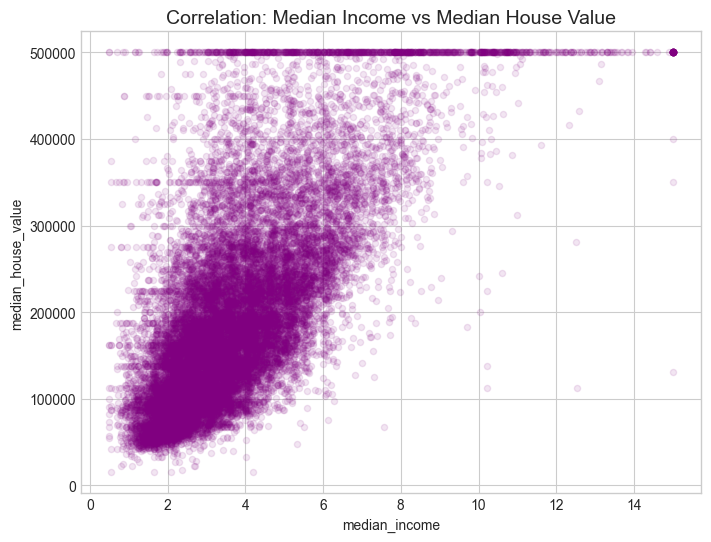

In [17]:
from pandas.plotting import scatter_matrix

# 1. In ra độ tương quan của các số liệu với biến mục tiêu (giá nhà)
print("Correlation with median_house_value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

# 2. Vẽ scatter matrix cho các features có mối tương quan mạnh nhất
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(df[attributes], figsize=(12, 8), alpha=0.2)
plt.suptitle('Scatter Matrix (Tìm điểm tương quan giữa các Features chính)', fontsize=16)
plt.show()

# 3. Phóng to (Zoom) vào biểu đồ phân tán giữa Thu nhập và Giá nhà
df.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, figsize=(8, 6), color='purple')
plt.title("Correlation: Median Income vs Median House Value", fontsize=14)
plt.show()

### Nhận xét & Phân tích từ biểu đồ (EDA Insights)

Dựa trên các biểu đồ trực quan, ta có thể rút ra một số thông tin quan trọng sau:

1. **Phân phối dữ liệu (Histograms):**
   - **Bị giới hạn (Capped):** Hai biến `housing_median_age` (chặn ở mức trên 50) và `median_house_value` (chặn ở mức 500,000) có xuất hiện lượng lớn dữ liệu tích tụ ở giá trị biên lớn nhất. Cần có phương án xử lý (như xóa các điểm dữ liệu này nếu dự án yêu cầu dự đoán chính xác cả trên mức 500k).
   - **Dữ liệu lệch phải (Long-tail / Right-skewed):** Hầu hết các đặc trưng (ví dụ: `total_rooms`, `total_bedrooms`, `population`, `median_income`) đều bị lệch phải. Việc này gợi ý rằng ta nên áp dụng các phép biến đổi (như Log Transformation) để đưa phân phối về dạng chuẩn (normal distribution).
   - **Thang đo khác biệt (Scaling):** Các biến có thang đo rất khác nhau (ví dụ: `median_income` từ 0-15, trong khi `population` lên tới hàng nghìn). Cần thiết phải dùng *Feature Scaling* (Standardization hoặc Normalization) trước khi huấn luyện mô hình.

2. **Ma trận tương quan (Correlation Matrix):**
   - **Đặc trưng mục tiêu (`median_house_value`):** Tỉ lệ thuận rất mạnh với `median_income`. Thu nhập trung bình dường như là yếu tố mang tính quyết định nhất để dự báo giá nhà.
   - **Đa cộng tuyến (Multicollinearity):** Các biến `total_rooms`, `total_bedrooms`, `population`, và `households` có tương quan rất mạnh với nhau. Điều này hoàn toàn có lý (số hộ gia đình lớn đương nhiên cần nhiều nhà, nhiều phòng). Cần cân nhắc tạo thêm các đặc trưng kết hợp (Features Engineering) ví dụ như: số phòng trên mỗi hộ, dân số trên mỗi hộ để thuộc tính có ý nghĩa hơn.

3. **Biểu đồ phân tán địa lý (Geographical Scatter Plot):**
   - **Tác động của yếu tố vị trí:** Giá nhà tập trung cao đột biến ở vùng ven biển Đông (vùng Vịnh San Francisco, Los Angeles).
   - Kết hợp với màu sắc, đồ thị chứng tỏ giá trị bất động sản (*median house value*) phụ thuộc trực tiếp vào vị trí không gian. Các khu dân cư gần đại dương có khuynh hướng đắt đỏ hơn đáng kể so với đất liền.

## Extra 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

housing = pd.read_csv('..\..\Data\ML_extra\housing.csv')

### Task 01

1. Vẽ scatter plot laitude vs longitude với s=population/100, c=median_house_value, cmap='jet'.
2. Tính correlation matrix: housing.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False)
3. Tạo 3 features mới: room_per_house, bedroom_ratio, people_per_house
4. Tính lại correlation - các feature mới có cải thiện correlation không?
5. Dùng scatter_matrix() để vẽ top 4 feature tương quan cao nhất 

#### Q1

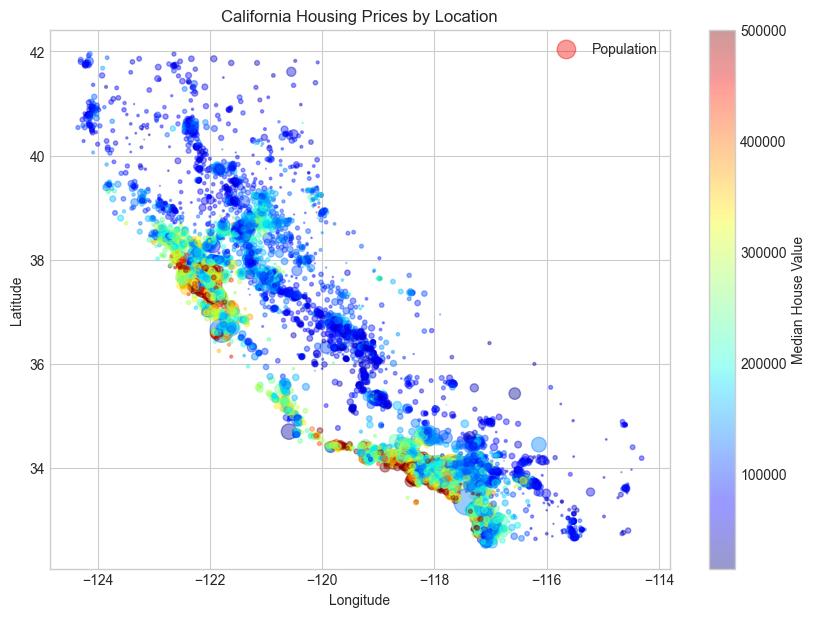

In [31]:
# Vẽ scatter plot Latitude vs Longitude

plt.figure(figsize=(10, 7))
plt.scatter(housing['longitude'], housing['latitude'], alpha=0.4,
            s=housing['population']/100, label='Population',
            c=housing['median_house_value'], cmap='jet')

plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')
plt.legend()
plt.show()

Assess:
Biểu đồ cho thấy giá nhà cao tập trung chủ yếu ở các vùng ven biển (như San Francisco và Los Angeles).

#### Q2

In [34]:
# Tính Correlation matrix ban đầu
corr_matrix = housing.corr(numeric_only=True)
target_corr_initial = corr_matrix['median_house_value'].sort_values(ascending=False)
print(target_corr_initial)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


Assess:
median_income (thu nhập trung bình) có hệ số tương quan thuận cao nhất (khoảng 0.68), là feature quan trọng nhất hiện tại.

#### Q3

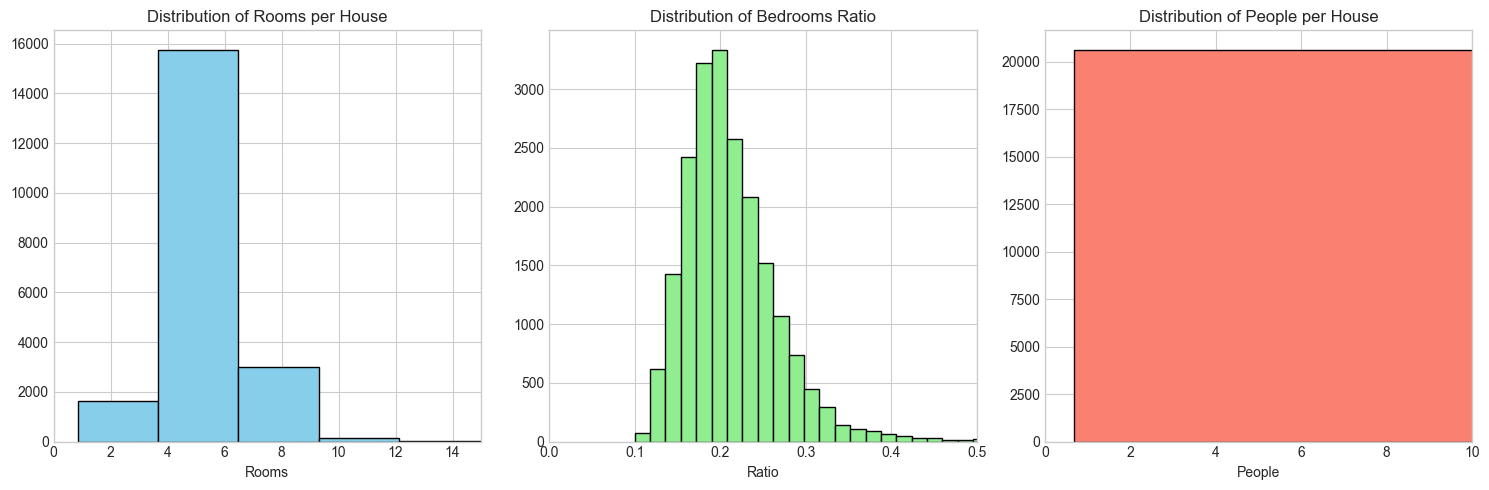

In [ ]:
# Tạo 3 features mới (Feature Engineering)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# 1. Rooms per house
housing['rooms_per_house'].hist(bins=50, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Rooms per House')
axes[0].set_xlabel('Rooms')
axes[0].set_xlim(0, 15) # Giới hạn trục X để hiển thị rõ phần lớn dữ liệu, loại trừ extreme outliers

# 2. Bedrooms ratio
housing['bedrooms_ratio'].hist(bins=50, ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Bedrooms Ratio')
axes[1].set_xlabel('Ratio')
axes[1].set_xlim(0, 0.5)

# 3. People per house
housing['people_per_house'].hist(bins=50, ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Distribution of People per House')
axes[2].set_xlabel('People')
axes[2].set_xlim(0, 10)

plt.tight_layout()
plt.show()

#### Q4

In [40]:
# Tính lại correlation - Đánh giá sự cải thiện
corr_matrix_new = housing.corr(numeric_only=True)
target_corr_new = corr_matrix_new['median_house_value'].sort_values(ascending=False)
print(target_corr_new)

median_house_value    1.000000
median_income         0.688075
rooms_per_house       0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
people_per_house     -0.023737
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedrooms_ratio       -0.255880
Name: median_house_value, dtype: float64


Assess:
Việc tạo feature mới đã cải thiện khả năng dự đoán.
- bedrooms_ratio đạt mức tương quan nghịch đáng kể (-0.256), mạnh thứ 2 trong bộ dữ liệu (tỷ lệ phòng ngủ cao thì giá nhà thường thấp hơn).
- rooms_per_house (0.152) tương quan tốt hơn hẳn so với total_rooms ban đầu (0.134).

#### Q5

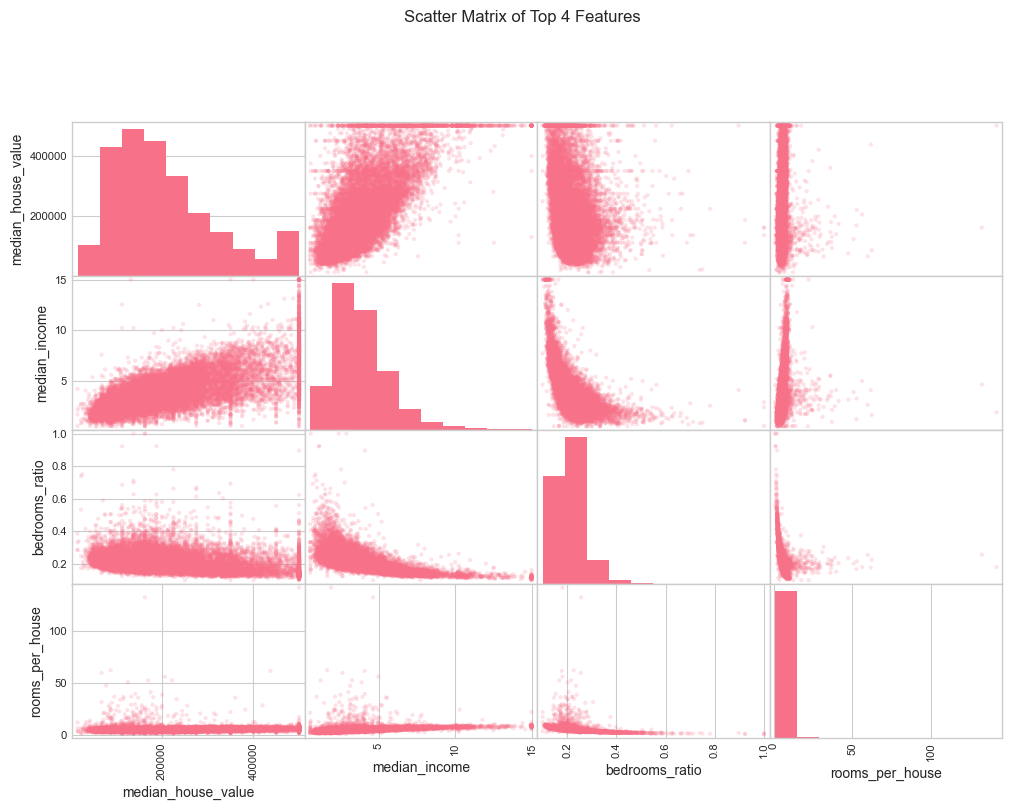

In [41]:
# Dùng scatter_matrix vẽ top 4 features
# Lấy tên 4 features có giá trị tương quan tuyệt đối (absolute) cao nhất
top_4_features = target_corr_new.abs().sort_values(ascending=False).index[:4].tolist()

# Vẽ Scatter Matrix
scatter_matrix(housing[top_4_features], figsize=(12, 8), alpha=0.2)
plt.suptitle('Scatter Matrix of Top 4 Features', y=1.02)
plt.show()

Assess:
Plot giữa median_income và median_house_value hiển thị rõ một đường thẳng ngang (price cap) tại mức giá 500,000 USD. Đây là dấu hiệu dữ liệu đã bị can thiệp cắt trần, cần lưu ý xử lý hoặc loại bỏ trước khi đưa vào mô hình học máy.

### Task 02

1. Tách X_ train = strat_train_set.drop('median_house_value', axis=1) và y_train
2. Tạo num_pipeline: SimpleImputer -> StandardScaler
3. Tạo cat_pipeline: SimpleImputer(strategy='most_frequent') -> OneHotEncoder
4. Kết hợp bằng ColumnTransformer hoặc make_column_transformer()
5. Gọi preprocessing.fit_transform(X_train) và kiểm tra shape output

In [43]:
housing["income_cat"] = pd.cut(housing["median_income"], 
                               bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf], 
                               labels=[1, 2, 3, 4, 5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]

strat_train_set = strat_train_set.drop("income_cat", axis=1)

# ==========================================
# THỰC HIỆN 5 BƯỚC YÊU CẦU
# ==========================================

# 1. Tách X_train (Features) và y_train (Target/Labels)
X_train = strat_train_set.drop('median_house_value', axis=1)
y_train = strat_train_set['median_house_value'].copy()

# Phân loại tự động các features số (numerical) và chữ (categorical)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = ["ocean_proximity"]

# 2. Tạo num_pipeline cho dữ liệu số
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Điền khuyết bằng trung vị (tránh ảnh hưởng outlier)
    ('std_scaler', StandardScaler())               # Chuẩn hóa (Z-score)
])

# 3. Tạo cat_pipeline cho dữ liệu phân loại
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Điền khuyết bằng giá trị xuất hiện nhiều nhất
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    # Mã hóa One-Hot
])

# 4. Kết hợp 2 pipeline bằng ColumnTransformer
preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# 5. Khớp (fit) và biến đổi (transform) trên X_train, sau đó kiểm tra kích thước
X_train_prepared = preprocessing.fit_transform(X_train)

print(f"Shape của X_train gốc: {X_train.shape}")
print(f"Shape của X_train_prepared: {X_train_prepared.shape}")

Shape của X_train gốc: (16512, 12)
Shape của X_train_prepared: (16512, 16)


### Task 03

1. Tại sao phải gọi fit() chỉ trên training data? Điều gì xảy ra nếu fit() trên toàn bộ dataset?
2. Stratified sampling quan trọng hơn random sampling trong trường hợp nào?
3. Khi EDA, bạn phát hiện feature median_income bị skewed. Bạn sẽ xử lý nó như thế nào?